In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [9]:
signal_csv_path = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/SAVED_RESULTS/S4D_GAUSSNLL_SNR_15_30_Mc_q_20260312/injected/signal.csv'
background_csv_path = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/SAVED_RESULTS/S4D_GAUSSNLL_SNR_15_30_Mc_q_20260312/background/background.csv'

In [28]:
BINS = {
    'chirp_mass': np.linspace(0.5, 3.0, 51),
    'mass_ratio': np.linspace(0.0, 1.0, 51),
    'mass1': np.linspace(0.5, 3.0, 51),
    'mass2': np.linspace(0.5, 3.0, 51),
}

SIGMA_BINS = {
    'chirp_mass': np.linspace(0.0, 1.0, 51),
    'mass_ratio': np.linspace(0.0, 1.0, 51),
    'mass1': np.linspace(0.0, 1.0, 51),
    'mass2': np.linspace(0.0, 1.0, 51),
}

LABEL = {
    'chirp_mass': r'$\mathcal{M}_{c}$',
    'mass_ratio': r'$q$',
    'mass1':      r'$m_1$',
    'mass2':      r'$m_2$',
}

SIGMA_LABEL = {
    'chirp_mass': r'$\sigma_{\mathcal{M}_{c}}$',
    'mass_ratio': r'$\sigma_{q}$',
    'mass1':      r'$\sigma_{m_1}$',
    'mass2':      r'$\sigma_{m_2}$',
}


In [10]:
# Read CSV files
signal_df = pd.read_csv(signal_csv_path)
background_df = pd.read_csv(background_csv_path)

In [14]:
def hist_outline(ax, data, bins, **kwargs):
    """Draw a histogram as a step outline (no fill)."""
    counts, edges = np.histogram(data, bins=bins)
    ax.stairs(counts, edges, **kwargs)

In [26]:
# ── unpack columns ────────────────────────────────────────────────────────
mchirp_pred_sig = signal_df['M_chirp_pred'].values
q_pred_sig = signal_df['M_ratio_pred'].values
sigma_mchirp_pred_sig = signal_df['sigma_M_chirp_pred'].values
sigma_q_pred_sig = signal_df['sigma_M_ratio_pred'].values

mchirp_pred_bkg = background_df['M_chirp_pred'].values
q_pred_bkg = background_df['M_ratio_pred'].values
sigma_mchirp_pred_bkg = background_df['sigma_M_chirp_pred'].values
sigma_q_pred_bkg = background_df['sigma_M_ratio_pred'].values

# ── derived quantities ────────────────────────────────────────────────────

z_mchirp_sig = (signal_df['M_chirp_pred'].values - signal_df['M_chirp_true'].values) / sigma_mchirp_pred_sig
z_q_sig = (signal_df['M_ratio_pred'].values - signal_df['M_ratio_true'].values) / sigma_q_pred_sig

z_mchirp_bkg = (background_df['M_chirp_pred'].values - background_df['M_chirp_true'].values) / sigma_mchirp_pred_bkg
z_q_bkg = (background_df['M_ratio_pred'].values - background_df['M_ratio_true'].values) / sigma_q_pred_bkg

# ── shared style ──────────────────────────────────────────────────────────
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                        'axes.spines.right': False})

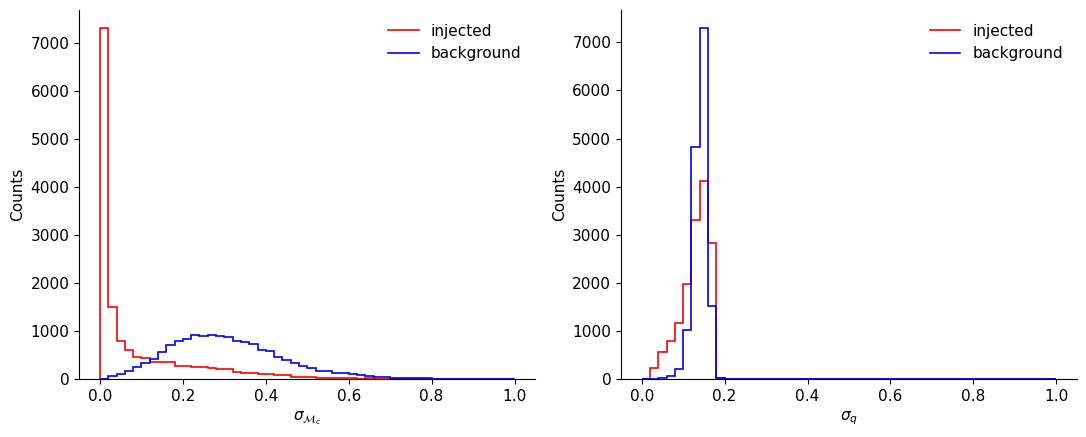

In [29]:
fig1, axes1 = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, sig, bkg, key in zip(
    axes1,
    [sigma_mchirp_pred_sig, sigma_q_pred_sig],
    [sigma_mchirp_pred_bkg, sigma_q_pred_bkg],
    ['chirp_mass', 'mass_ratio'],
):
    hist_outline(ax, sig, bins=SIGMA_BINS[key], color='red',   linewidth=1.2, label='injected')
    hist_outline(ax, bkg, bins=SIGMA_BINS[key], color='blue', linewidth=1.2, label='background')
    ax.set_xlabel(SIGMA_LABEL[key])
    ax.set_ylabel('Counts')
    ax.legend(frameon=False)

fig1.tight_layout()

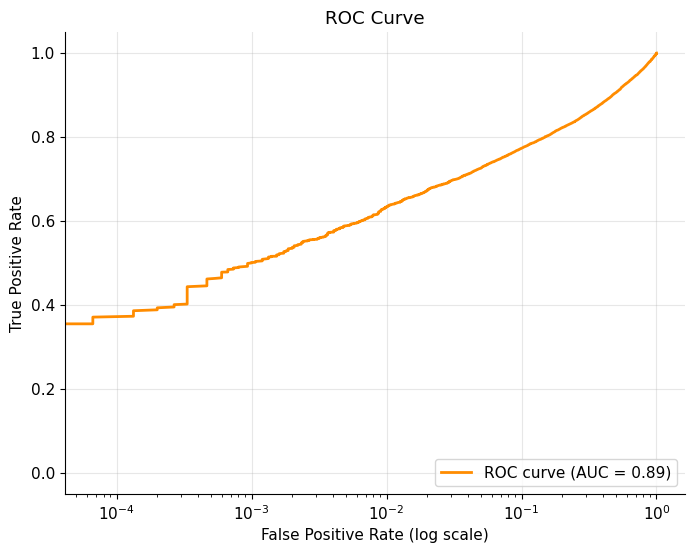

In [49]:
# Create ROC curve using sigma_M_ratio_pred as discriminator
y_true = np.concatenate([np.ones(len(signal_df)), np.zeros(len(background_df))])
y_score = np.concatenate([sigma_mchirp_pred_sig, sigma_mchirp_pred_bkg])

# Compute ROC curve manually
thresholds = np.linspace(0, 1, 10000)
tpr_list = []
fpr_list = []

for threshold in thresholds:
    tp = np.sum((y_score <= threshold) & (y_true == 1))
    fp = np.sum((y_score <= threshold) & (y_true == 0))
    fn = np.sum((y_score > threshold) & (y_true == 1))
    tn = np.sum((y_score > threshold) & (y_true == 0))
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    tpr_list.append(tpr)
    fpr_list.append(fpr)

fpr = np.array(fpr_list)
tpr = np.array(tpr_list)

# Compute AUC using trapezoidal rule
roc_auc = np.trapezoid(tpr, fpr)

# Plot ROC curve with log scale on x-axis
plt.figure(figsize=(8, 6))
plt.semilogx(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate (log scale)')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()